<a href="https://colab.research.google.com/github/Arnav111garg/Basic_Quant-ML_projects/blob/main/Multi_Factor_Alpha_Model_with_Feature_Importance_and_Interaction_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### ***Random Forest***


**Random Forest is a machine learning algorithm that uses many decision trees to make better predictions. Each tree looks at different random parts of the data and their results are combined by voting for classification or averaging for regression which makes it as ensemble learning technique. This helps in improving accuracy and reducing errors.**

### ***Working of Random Forest Algorithm***

- ***Create Many Decision Trees:***

**The algorithm makes many decision trees each using a random part of the data. So every tree is a bit different.**

- ***Pick Random Features:***

**When building each tree it doesn’t look at all the features (columns) at once. It picks a few at random to decide how to split the data. This helps the trees stay different from each other.**

- ***Each Tree Makes a Prediction:***

**Every tree gives its own answer or prediction based on what it learned from its part of the data.
Combine the Predictions: For classification, the final answer is the category that most trees vote for (majority voting).**

- ***Why It Works Well:***

**Using random data and features for each tree helps avoid overfitting and makes the overall prediction more accurate and trustworthy.**

### ***Key Features of Random Forest***

- ***Handles Missing Data:***

**It can work even if some data is missing so you don’t always need to fill in the gaps yourself.**


- ***Shows Feature Importance:***

**It tells you which features (columns) are most useful for making predictions which helps you understand your data better.**


- ***Works Well with Big and Complex Data:***

**It can handle large datasets with many features without slowing down or losing accuracy.**


- ***Used for Different Tasks:***

**You can use it for both classification like predicting types or labels and regression like predicting numbers or amounts.**

### ***Multi-Factor Alpha Model with Feature Importance and Interaction Analysis***

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV
import shap

data = yf.download('^NSEI', start="2015-01-01", end="2026-01-04")
data.columns = data.columns.get_level_values(0)
data.head()

/tmp/ipykernel_3384/3390513795.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('^NSEI', start="2015-01-01", end="2026-01-04")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,8395.450195,8410.599609,8288.700195,8288.700195,101900
2015-01-05,8378.400391,8445.599609,8363.900391,8407.950195,118200
2015-01-06,8127.350098,8327.849609,8111.350098,8325.299805,172800
2015-01-07,8102.100098,8151.200195,8065.450195,8118.649902,164100
2015-01-08,8234.599609,8243.500000,8167.299805,8191.399902,143800


In [ ]:
data['Returns'] = data['Close'].pct_change()

# Factor 1: Momentum (21-day)
data['Momentum'] = data['Close'].pct_change(21)

# Factor 2: Volatility (21-day rolling Std Dev)
data['Volatility'] = data['Returns'].rolling(window=21).std()

# Factor 3: Relative Volume
data['Rel_Volume'] = data['Volume'] / data['Volume'].rolling(window=21).mean()

# Target Variable: 5-Day Forward Return (Look-ahead)
data['Target'] = data['Close'].shift(-5).pct_change(5)

df = data[['Momentum', 'Volatility', 'Rel_Volume', 'Target']].dropna()

/tmp/ipykernel_3384/1178639564.py:13: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['Target'] = data['Close'].shift(-5).pct_change(5)


In [ ]:
X = df[['Momentum', 'Volatility', 'Rel_Volume']]
y = df['Target']

split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

predictions = rf_model.predict(X_test)

/tmp/ipykernel_3384/1373914311.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


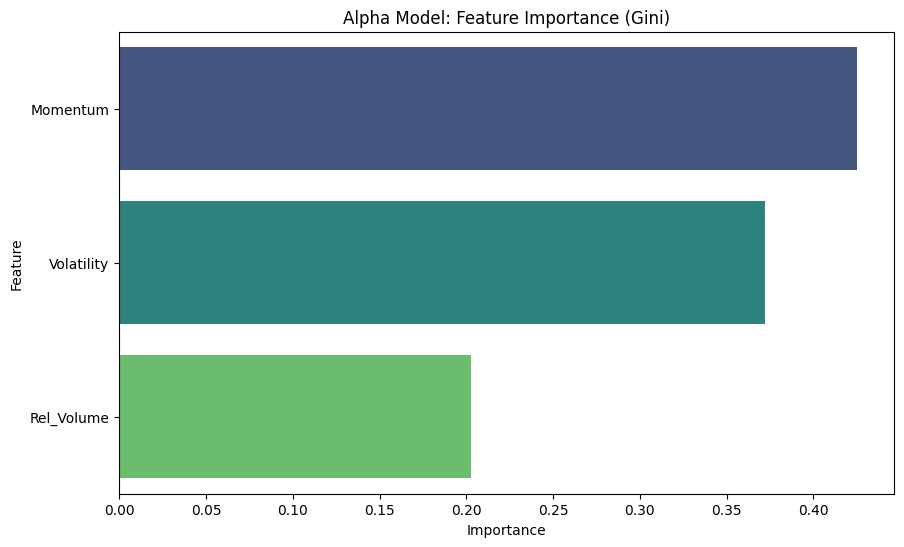

In [ ]:
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Alpha Model: Feature Importance (Gini)')
plt.show()

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [5, 10, 20, 50],
    'max_features': ['sqrt', 'log2']}

rf = RandomForestRegressor()
random_search = RandomizedSearchCV(rf, param_distributions=param_dist,
                                   n_iter=10, cv=tscv, scoring='neg_mean_squared_error')
random_search.fit(X, y)

best_rf = random_search.best_estimator_
print(f"Best Parameters: {random_search.best_params_}")

Best Parameters: {'n_estimators': 500, 'min_samples_leaf': 50, 'max_features': 'sqrt', 'max_depth': 3}


In [ ]:
# Calculating Accuracy
predictions = best_rf.predict(X_test)
actual_direction = (y_test > 0).astype(int)
predicted_direction = (predictions > 0).astype(int)
accuracy = accuracy_score(actual_direction, predicted_direction)
print(f"Directional Accuracy: {accuracy}")

# Calculating Sharpe
strategy_returns = np.sign(predictions) * y_test
avg_return = strategy_returns.mean()
std_return = strategy_returns.std()
annualization_factor = np.sqrt(252 / 5)
sharpe_ratio = (avg_return / std_return) * annualization_factor
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")

Directional Accuracy: 0.5580357142857143
Annualized Sharpe Ratio: 0.79


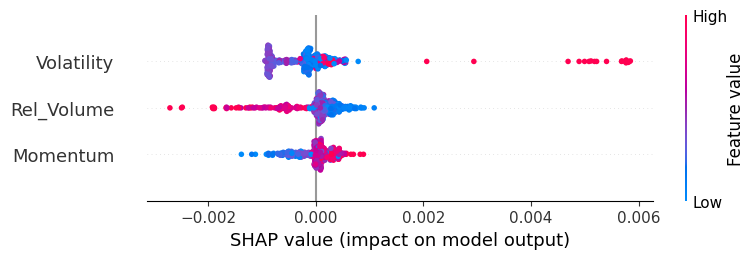

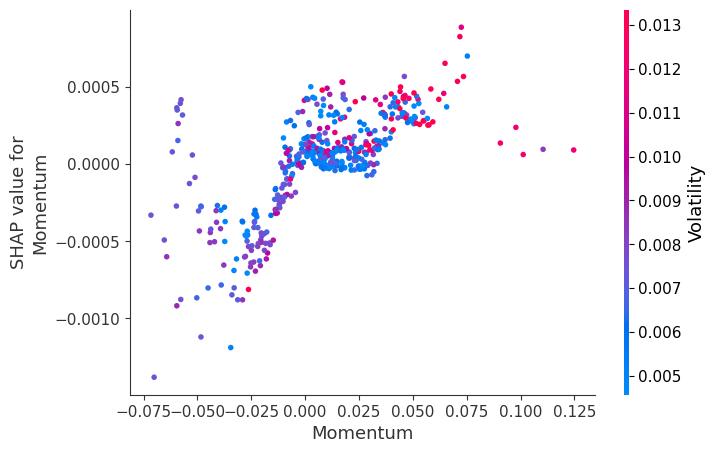

In [ ]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

# This shows how Volatility changes the impact of Momentum
shap.dependence_plot("Momentum", shap_values, X_test, interaction_index="Volatility")